# Formal cross-condition statistics

In [ ]:
import pandas as pd
from pathlib import Path

csv_path = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "final_results/data/"
    "cross_condition_cross_seed_master.csv"
)

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nRows:")
display(df)

In [ ]:
print("All columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

In [ ]:
metrics = [
    "disease_f1",
    "chemical_f1",
    "rouge_l",
    "bertscore_f1",
    "cosine_similarity",
    "word_count",
    "repetition_rate",
    "perplexity"
]

g0 = df[df["generation"] == "G0"].set_index(["condition", "seed"])
g3 = df[df["generation"] == "G3"].set_index(["condition", "seed"])

delta = g3[metrics] - g0[metrics]
delta = delta.reset_index()

print("G0 → G3 change:")
display(delta)

In [ ]:
# Difference-in-differences: Recursive change minus Human Control change

recursive = delta[delta["condition"] == "Recursive"].set_index("seed")
control = delta[delta["condition"] == "Human_Control"].set_index("seed")

did = recursive[metrics] - control[metrics]

print("Difference-in-differences (Recursive − Human Control):")
display(did)

In [ ]:
stats_path = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "final_results/data/"
    "cross_condition_cross_seed_paired_statistical_analysis_master.csv"
)

stats_df = pd.read_csv(stats_path)

print("Shape:", stats_df.shape)
print("\nColumns:")
for i, col in enumerate(stats_df.columns, 1):
    print(f"{i}. {col}")

In [ ]:
print("Comparisons available:")
display(
    stats_df["comparison"]
    .value_counts()
    .sort_index()
)

In [ ]:
print("Metrics included in statistical analysis:")
display(
    stats_df["metric"]
    .value_counts()
    .sort_index()
)

In [ ]:
important_metrics = [
    "Disease F1",
    "Chemical F1",
    "ROUGE-L",
    "BERTScore F1",
    "Cosine similarity",
    "Perplexity"
]

g0_g3_stats = stats_df[
    (stats_df["comparison"] == "G0 → G3") &
    (stats_df["metric"].isin(important_metrics))
].copy()

g0_g3_stats = g0_g3_stats.sort_values(
    ["metric", "condition", "seed"]
)

display(g0_g3_stats)

In [ ]:
from pathlib import Path

base = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
)

print("CSV files under 0.5B evaluation:")
for p in sorted(base.rglob("*.csv")):
    print(p.relative_to(base))

In [ ]:
from pathlib import Path

project_root = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
)

matches = []

for p in project_root.rglob("*"):
    if p.is_file() and (
        "per_sample" in p.name.lower()
        or "domain_behavioral" in p.name.lower()
        or "context_support" in p.name.lower()
    ):
        matches.append(p)

print("Matching files:", len(matches))

for p in matches:
    print(p.relative_to(project_root))

In [ ]:
from pathlib import Path

content = Path("/content")

patterns = [
    "combined_lexical_semantic_domain_per_sample.csv",
    "combined_domain_behavioral_per_sample.csv",
]

found = []

for p in content.rglob("*"):
    if p.is_file() and p.name in patterns:
        found.append(p)

print("Found:", len(found))

for p in found:
    print(p)

In [ ]:
from pathlib import Path

for p in sorted(Path("/mnt/data").glob("*0.5B*")):
    print(p)

In [ ]:
from pathlib import Path

p = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "combined_evaluation_seed42_0.5b_colab.ipynb"
)

print("Exists:", p.exists())
print("Path:", p)

In [ ]:
from pathlib import Path

root = Path("/content")

print("Files directly under /content:")
for p in sorted(root.iterdir()):
    print(p.name)

In [ ]:
from pathlib import Path

root = Path("/content/recursive_project")

for p in root.rglob("*.csv"):
    print(p)

In [ ]:
from zipfile import ZipFile
from pathlib import Path

zip_path = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-0.5b/"
    "final_results/data.zip"
)

print("Exists:", zip_path.exists())

with ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Files inside data.zip:", len(files))

for f in files:
    print(f)

In [ ]:
from pathlib import Path

for p in sorted(Path("/content").rglob("*.zip")):
    print(p)

In [ ]:
from pathlib import Path
import pandas as pd

path_3b = Path(
    "/content/recursive_project/"
    "recursive-llm-degradation-research-main/"
    "notebooks/evaluation_qwen2.5-3b/"
    "final_results/data/"
    "cross_condition_cross_seed_master.csv"
)

df_3b = pd.read_csv(path_3b)

print("0.5B shape:", df.shape)
print("3B shape :", df_3b.shape)

print("\n0.5B columns:")
print(df.columns.tolist())

print("\n3B columns:")
print(df_3b.columns.tolist())

print("\n0.5B conditions:")
print(df["condition"].value_counts())

print("\n3B conditions:")
print(df_3b["condition"].value_counts())

print("\n0.5B generations:")
print(sorted(df["generation"].unique()))

print("\n3B generations:")
print(sorted(df_3b["generation"].unique()))

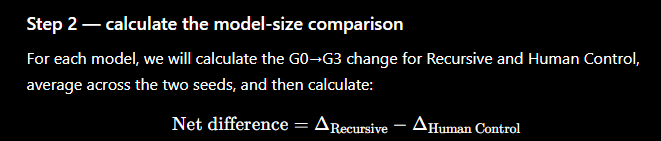

In [ ]:
metrics_core = [
    "disease_f1",
    "chemical_f1",
    "context_supported_rate",
    "context_unsupported_rate",
    "rouge_l",
    "bertscore_f1",
    "cosine_similarity",
    "word_count",
    "repetition_rate",
    "perplexity"
]

def calculate_model_deltas(data, model_name):
    g0 = data[data["generation"] == "G0"].set_index(["condition", "seed"])
    g3 = data[data["generation"] == "G3"].set_index(["condition", "seed"])

    delta = g3[metrics_core] - g0[metrics_core]

    rows = []

    for condition in ["Recursive", "Human_Control"]:
        values = delta.loc[condition]

        for metric in metrics_core:
            rows.append({
                "model": model_name,
                "condition": condition,
                "metric": metric,
                "mean_delta": values[metric].mean(),
                "seed42_delta": values.loc[42, metric],
                "seed123_delta": values.loc[123, metric],
            })

    return pd.DataFrame(rows)


delta_05b = calculate_model_deltas(df, "Qwen2.5-0.5B")
delta_3b = calculate_model_deltas(df_3b, "Qwen2.5-3B")

model_deltas = pd.concat(
    [delta_05b, delta_3b],
    ignore_index=True
)

display(model_deltas)

In [ ]:
# Calculate the Recursive-vs-Control effect for each model
# and then compare that effect between 0.5B and 3B.

effect_rows = []

for model in ["Qwen2.5-0.5B", "Qwen2.5-3B"]:
    rec = model_deltas[
        (model_deltas["model"] == model) &
        (model_deltas["condition"] == "Recursive")
    ].set_index("metric")

    ctrl = model_deltas[
        (model_deltas["model"] == model) &
        (model_deltas["condition"] == "Human_Control")
    ].set_index("metric")

    for metric in metrics_core:
        rec_delta = rec.loc[metric, "mean_delta"]
        ctrl_delta = ctrl.loc[metric, "mean_delta"]

        effect_rows.append({
            "model": model,
            "metric": metric,
            "recursive_delta": rec_delta,
            "control_delta": ctrl_delta,
            "recursive_minus_control": rec_delta - ctrl_delta
        })

effects = pd.DataFrame(effect_rows)

# Compare model-size effects
effect_05b = effects[
    effects["model"] == "Qwen2.5-0.5B"
].set_index("metric")

effect_3b = effects[
    effects["model"] == "Qwen2.5-3B"
].set_index("metric")

model_size_comparison = pd.DataFrame({
    "effect_0.5B": effect_05b["recursive_minus_control"],
    "effect_3B": effect_3b["recursive_minus_control"],
})

model_size_comparison["3B_minus_0.5B"] = (
    model_size_comparison["effect_3B"]
    - model_size_comparison["effect_0.5B"]
)

display(model_size_comparison)

In [ ]:
# Seed-level Recursive-vs-Control effects for each model

seed_effect_rows = []

for model in ["Qwen2.5-0.5B", "Qwen2.5-3B"]:
    for seed in [42, 123]:

        rec = model_deltas[
            (model_deltas["model"] == model) &
            (model_deltas["condition"] == "Recursive")
        ].set_index("metric")

        ctrl = model_deltas[
            (model_deltas["model"] == model) &
            (model_deltas["condition"] == "Human_Control")
        ].set_index("metric")

        # Retrieve the seed-specific G0->G3 changes
        for metric in metrics_core:
            rec_delta = rec.loc[metric, f"seed{seed}_delta"]
            ctrl_delta = ctrl.loc[metric, f"seed{seed}_delta"]

            seed_effect_rows.append({
                "model": model,
                "seed": seed,
                "metric": metric,
                "recursive_minus_control": rec_delta - ctrl_delta
            })

seed_effects = pd.DataFrame(seed_effect_rows)

display(seed_effects)

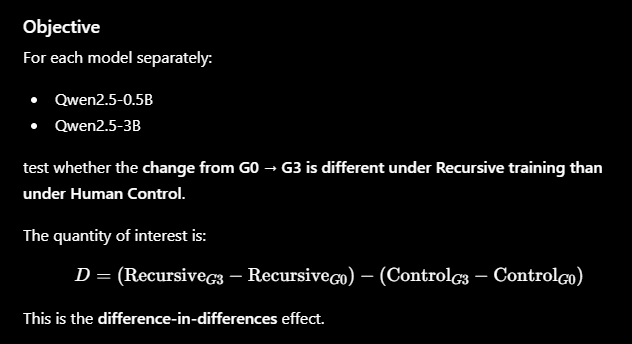

# Final Statistical Synthesis
This section consolidates the completed 0.5B and 3B master results. It separates within-condition G0→G3 inference already computed in the project from the Recursive-versus-Human-Control effect magnitude and the model-size interaction, which are descriptive across the two tested seeds.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/content/recursive_project/recursive-llm-degradation-research-main/notebooks")
MASTER_05B = ROOT / "evaluation_qwen2.5-0.5b/final_results/data/cross_condition_cross_seed_master.csv"
MASTER_3B = ROOT / "evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_master.csv"
STATS_05B = ROOT / "evaluation_qwen2.5-0.5b/final_results/data/cross_condition_cross_seed_paired_statistical_analysis_master.csv"
STATS_3B = ROOT / "evaluation_qwen2.5-3b/final_results/data/cross_condition_cross_seed_paired_statistical_analysis_master.csv"

master_05b = pd.read_csv(MASTER_05B)
master_3b = pd.read_csv(MASTER_3B)
stats_05b = pd.read_csv(STATS_05B)
stats_3b = pd.read_csv(STATS_3B)

print("0.5B master:", master_05b.shape)
print("3B master :", master_3b.shape)
print("0.5B stats:", stats_05b.shape)
print("3B stats :", stats_3b.shape)

In [ ]:
CORE_METRICS = [
    "disease_f1", "chemical_f1",
    "context_supported_rate", "context_unsupported_rate",
    "rouge_l", "bertscore_f1", "cosine_similarity",
    "word_count", "repetition_rate", "perplexity"
]

def g0_g3_effects(master, model_name):
    g0 = master[master["generation"] == "G0"].set_index(["condition", "seed"])
    g3 = master[master["generation"] == "G3"].set_index(["condition", "seed"])
    delta = g3[CORE_METRICS] - g0[CORE_METRICS]
    rows = []
    for metric in CORE_METRICS:
        rec = delta.loc["Recursive", metric]
        ctrl = delta.loc["Human_Control", metric]
        d = rec - ctrl
        rows.append({
            "model": model_name,
            "metric": metric,
            "recursive_mean_delta": rec.mean(),
            "control_mean_delta": ctrl.mean(),
            "recursive_minus_control": d.mean(),
            "seed42_effect": d.loc[42],
            "seed123_effect": d.loc[123],
        })
    return pd.DataFrame(rows)

condition_effects = pd.concat([
    g0_g3_effects(master_05b, "Qwen2.5-0.5B"),
    g0_g3_effects(master_3b, "Qwen2.5-3B"),
], ignore_index=True)

display(condition_effects.round(6))

In [ ]:
wide = condition_effects.pivot(index="metric", columns="model", values="recursive_minus_control")
wide["3B_minus_0.5B"] = wide["Qwen2.5-3B"] - wide["Qwen2.5-0.5B"]

seed42_wide = condition_effects.pivot(index="metric", columns="model", values="seed42_effect")
seed42_interaction = seed42_wide["Qwen2.5-3B"] - seed42_wide["Qwen2.5-0.5B"]

seed123_wide = condition_effects.pivot(index="metric", columns="model", values="seed123_effect")
seed123_interaction = seed123_wide["Qwen2.5-3B"] - seed123_wide["Qwen2.5-0.5B"]

model_size_interaction = wide[["Qwen2.5-0.5B", "Qwen2.5-3B", "3B_minus_0.5B"]].copy()
model_size_interaction["seed42_interaction"] = seed42_interaction
model_size_interaction["seed123_interaction"] = seed123_interaction

display(model_size_interaction.round(6))

Existing within-condition inferential results
The project master statistical files already contain paired G0→G3 bootstrap confidence intervals, Cohen's dz, and Wilcoxon tests within each condition and seed. These p-values test generation change within a condition; they are not direct Recursive-vs-Control p-values.

In [ ]:
KEY_STAT_METRICS = [
    "Disease F1", "Chemical F1", "ROUGE-L",
    "BERTScore F1", "Cosine similarity", "Perplexity"
]

def select_g0_g3(stats, model_name):
    x = stats[(stats["comparison"] == "G0 → G3") & (stats["metric"].isin(KEY_STAT_METRICS))].copy()
    x.insert(0, "model", model_name)
    return x[["model", "condition", "seed", "metric", "n", "mean_change", "ci_95_low", "ci_95_high", "cohens_dz", "wilcoxon_p"]]

within_condition_inference = pd.concat([
    select_g0_g3(stats_05b, "Qwen2.5-0.5B"),
    select_g0_g3(stats_3b, "Qwen2.5-3B"),
], ignore_index=True)

display(within_condition_inference.sort_values(["metric", "model", "condition", "seed"]).round(6))

Interpretation guardrails
Within-condition inference: use the existing bootstrap CI / Wilcoxon / Cohen's dz values above to describe G0→G3 changes within Recursive or Human Control.
Recursive-vs-Control effect: use recursive_minus_control as the difference-in-differences effect magnitude.
Model-size interaction: use 3B_minus_0.5B as a descriptive interaction across the two tested seeds. With only two seeds per model, do not report a conventional population-level significance test for this interaction.
Do not treat within-condition Wilcoxon p-values as tests of the Recursive-versus-Control contrast.

In [ ]:
OUT = Path("/content/final_analysis")
OUT.mkdir(parents=True, exist_ok=True)
condition_effects.to_csv(OUT / "condition_effects_g0_g3.csv", index=False)
model_size_interaction.reset_index().to_csv(OUT / "model_size_interaction.csv", index=False)
within_condition_inference.to_csv(OUT / "within_condition_inference_g0_g3.csv", index=False)
print("Saved:", OUT)
for p in sorted(OUT.glob("*.csv")):
    print(p.name)

In [ ]:
import matplotlib.pyplot as plt

PLOT_METRICS = ["disease_f1", "context_supported_rate", "rouge_l", "bertscore_f1", "cosine_similarity", "word_count"]
plot_df = model_size_interaction.loc[PLOT_METRICS]
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(PLOT_METRICS))
width = 0.36
ax.bar(x - width/2, plot_df["Qwen2.5-0.5B"], width, label="Qwen2.5-0.5B")
ax.bar(x + width/2, plot_df["Qwen2.5-3B"], width, label="Qwen2.5-3B")
ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(PLOT_METRICS, rotation=35, ha="right")
ax.set_ylabel("Recursive − Human Control G0→G3 effect")
ax.set_title("Recursive-vs-Control effect by model size")
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import shutil
from google.colab import files

folder = Path("/content/final_analysis")

print("Folder exists:", folder.exists())
print("Contents:")
for p in folder.rglob("*"):
    print(p.relative_to(folder))

zip_path = shutil.make_archive(
    "/content/final_analysis",
    "zip",
    root_dir=folder
)

print("\nCreated:", zip_path)

files.download(zip_path)